# K-Means Clustering and Choosing k

## Overview

This notebook applies K-Means to an unlabeled numeric dataset and focuses on the two decisions that matter most for this experiment: scaling the features and choosing a reasonable number of clusters.

The workflow is:

1. load and inspect the numeric features,
2. scale them with `StandardScaler`,
3. run K-Means for `k=1` through `k=10`,
4. use the elbow curve to narrow the choice,
5. compare the strongest candidates with the silhouette score,
6. fit the final model,
7. inspect the centroids and cluster profiles,
8. visualize the final clusters using two original features.

The class target that comes with the dataset is not used for clustering.

## Supervised vs Unsupervised Learning

In supervised learning, the model is trained against a known target and the prediction can be compared with the correct answer.

In unsupervised learning, there is no target used during fitting. The goal is to find structure in the feature space itself. For clustering, that structure is a set of observations that are more similar to each other than to observations in other groups.

This also changes evaluation. There is no normal prediction-vs-target score, so the clustering has to be checked with internal measures such as inertia and silhouette score, then interpreted from the original features.

## How K-Means Works

For a chosen number of clusters `k`, K-Means repeats two main operations:

1. assign every observation to its nearest centroid;
2. move each centroid to the mean position of the observations currently assigned to it.

The assignments and centroid positions are updated until the solution stabilizes.

The distance step decides which cluster a point belongs to. The mean step decides the new centroid location.

## 1. Imports

Only the tools needed for the Day 1 experiment are used here.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## 2. Load the Dataset

I use Scikit-learn's Wine dataset because it is small, fully numeric, and has enough features to make scaling relevant.

Only the feature matrix is used. The provided class labels are intentionally left out of the clustering process.

In [2]:
wine = load_wine(as_frame=True)

df = wine.data.copy()

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3. Basic Inspection

The checks here are limited to what affects K-Means: dataset size, data types, missing values, and feature ranges.

In [3]:
print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes.value_counts())

print("\nMissing values:", df.isna().sum().sum())

df.describe().T[["mean", "std", "min", "max"]].round(2)

Shape: (178, 13)

Data types:
float64    13
Name: count, dtype: int64

Missing values: 0


,mean,std,min,max
alcohol,13.00,0.81,11.03,14.83
malic_acid,2.34,1.12,0.74,5.80
ash,2.37,0.27,1.36,3.23
alcalinity_of_ash,19.49,3.34,10.60,30.00
magnesium,99.74,14.28,70.00,162.00
total_phenols,2.30,0.63,0.98,3.88
flavanoids,2.03,1.00,0.34,5.08
nonflavanoid_phenols,0.36,0.12,0.13,0.66
proanthocyanins,1.59,0.57,0.41,3.58
color_intensity,5.06,2.32,1.28,13.00


### Inspection

All 13 input columns are numeric and there are no missing values.

The feature ranges are clearly different. `proline`, for example, is measured on a much larger numeric scale than features such as `hue` or `nonflavanoid_phenols`. Since K-Means assigns clusters using distance, fitting directly on these raw values would give the large-scale features too much influence.

## 4. Scale the Features

`StandardScaler` centers each feature around zero and scales it to unit variance. This puts the features on a comparable scale before distances are calculated.

In [4]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    X_scaled,
    columns=df.columns,
    index=df.index,
)

scaled_df.describe().T[["mean", "std"]].round(3)

,mean,std
alcohol,-0.0,1.003
malic_acid,-0.0,1.003
ash,-0.0,1.003
alcalinity_of_ash,-0.0,1.003
magnesium,-0.0,1.003
total_phenols,0.0,1.003
flavanoids,-0.0,1.003
nonflavanoid_phenols,0.0,1.003
proanthocyanins,-0.0,1.003
color_intensity,0.0,1.003


### Scaling Check

The scaled feature means are approximately zero and their standard deviations are approximately one. K-Means will therefore compare observations using the standardized feature space rather than the original measurement scales.

## 5. Elbow Method

K-Means needs `k` before fitting. I run the algorithm from `k=1` to `k=10` and record the inertia for each model.

Inertia is the sum of squared distances from every observation to the centroid of its assigned cluster. It always decreses as more clusters are added, so the useful part of the curve is where the improvement starts to slow down.

In [5]:
inertias = []

for k in range(1, 11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )
    model.fit(X_scaled)
    inertias.append(model.inertia_)

elbow_results = pd.DataFrame({
    "k": range(1, 11),
    "inertia": inertias,
})

elbow_results.round(2)

,k,inertia
0,1,2314.00
1,2,1658.76
2,3,1277.93
3,4,1175.43
4,5,1109.51
5,6,1046.00
6,7,981.60
7,8,935.20
8,9,889.89
9,10,845.90


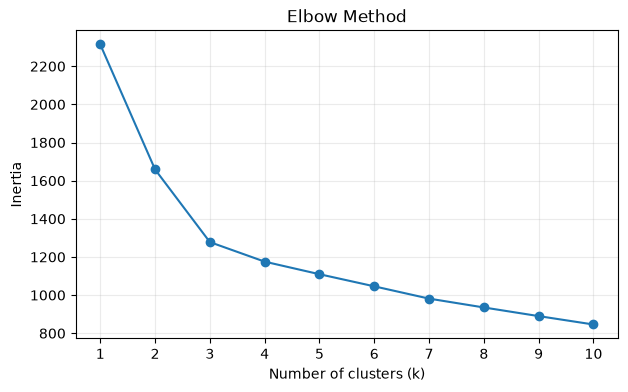

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(elbow_results["k"], elbow_results["inertia"], marker="o")
plt.xticks(range(1, 11))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(alpha=0.25)
plt.show()

### Elbow Result

The largest reductions happen early in the curve, and the improvement becomes noticeably smaller after about `k=3`.

The elbow is not a mathematical proof, so I keep `k=2` and `k=3` as the two candidates and compare them with the silhouette score.

## 6. Silhouette Score

The silhouette score checks the clustering from another angle.

For each observation, it compares:

- how close the observation is to other points in its own cluster,
- how far it is from the nearest competing cluster.

Higher values indicate better cohesion and separation. Unlike inertia, the silhouette score cannot be calculated for `k=1` because there is no second cluster to compare against.

In [7]:
candidate_k = [2, 3]
silhouette_results = []

for k in candidate_k:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )
    labels = model.fit_predict(X_scaled)

    silhouette_results.append({
        "k": k,
        "silhouette_score": silhouette_score(X_scaled, labels),
    })

silhouette_results = pd.DataFrame(silhouette_results)

silhouette_results.round(4)

,k,silhouette_score
0,2,0.2593
1,3,0.2849


### Choosing k

`k=3` has the stronger silhouette score of the two candidates, and it is also consistent with the elbow region.

I therefore use `k=3` for the final K-Means model.

The silhouette value is useful for comparing these candidtes, but it should not be read like an accuracy score. It measures geometric separation in the feature space.

## 7. Fit the Final K-Means Model

The final model uses the scaled features and the selected `k=3`.

In [8]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10,
)

cluster_labels = kmeans.fit_predict(X_scaled)

clustered_df = df.copy()
clustered_df["cluster"] = cluster_labels

print("Final inertia:", round(kmeans.inertia_, 2))
print("Final silhouette score:", round(silhouette_score(X_scaled, cluster_labels), 4))

print("\nCluster sizes:")
print(clustered_df["cluster"].value_counts().sort_index())

Final inertia: 1277.93
Final silhouette score: 0.2849

Cluster sizes:
cluster
0    65
1    51
2    62
Name: count, dtype: int64


## 8. Inspect the Centroids

K-Means learns the centroids in standardized space. For interpretation, I convert them back to the original feature units.

In [9]:
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)

centroids_df = pd.DataFrame(
    centroids_original,
    columns=df.columns,
    index=[f"Cluster {i}" for i in range(kmeans.n_clusters)],
)

centroids_df.round(2)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
Cluster 0,12.25,1.90,2.23,20.06,92.74,2.25,2.05,0.36,1.62,2.97,1.06,2.80,510.17
Cluster 1,13.13,3.31,2.42,21.24,98.67,1.68,0.82,0.45,1.15,7.23,0.69,1.70,619.06
Cluster 2,13.68,2.00,2.47,17.46,107.97,2.85,3.00,0.29,1.92,5.45,1.07,3.16,1100.23


## 9. Cluster Profiles

A centroid is the mean location of a cluster across all features, so grouping the original observations by cluster gives the same interpretation in familiar units.

I keep a smaller set of features in the summary so the main differences are easier to read.

In [10]:
profile_features = [
    "alcohol",
    "malic_acid",
    "flavanoids",
    "color_intensity",
    "hue",
    "proline",
]

cluster_profiles = (
    clustered_df
    .groupby("cluster")[profile_features]
    .mean()
    .round(2)
)

cluster_profiles

,alcohol,malic_acid,flavanoids,color_intensity,hue,proline
cluster,,,,,,
0,12.25,1.90,2.05,2.97,1.06,510.17
1,13.13,3.31,0.82,7.23,0.69,619.06
2,13.68,2.00,3.00,5.45,1.07,1100.23


### Cluster Interpretation

The three clusters have noticeably different profiles:

- **Cluster 0** has the lowest average alcohol, lower color intensity, and the lowest average proline of the three groups.
- **Cluster 1** has the highest average malic acid and color intensity, while its flavanoids and hue are the lowest.
- **Cluster 2** has the highest average alcohol, flavanoids, and proline.

These descriptions come from the feature values after clustering; no class label was used to create or name the groups.

The numeric cluster IDs (`0`, `1`, `2`) are only identifiers and do not imply an order.

## 10. Visualize the Final Clusters

The model was fitted using all 13 standardized features. The plot below only uses `flavanoids` and `proline` so the result can be viewed in two dimensions.

This plot is therefore a projection of the clustering result, not the full space used by K-Means.

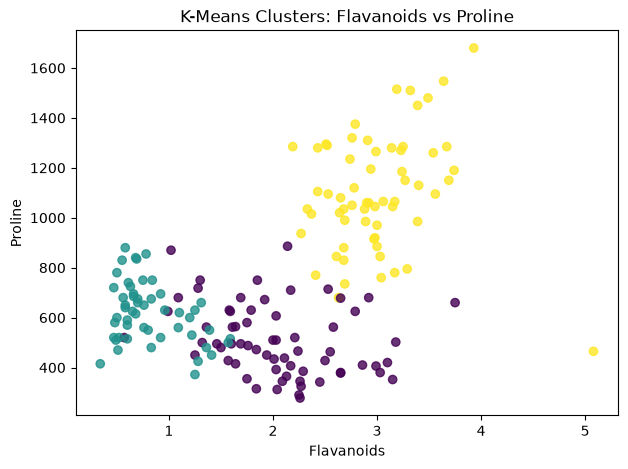

In [11]:
plt.figure(figsize=(7, 5))

plt.scatter(
    clustered_df["flavanoids"],
    clustered_df["proline"],
    c=clustered_df["cluster"],
    alpha=0.8,
)

plt.xlabel("Flavanoids")
plt.ylabel("Proline")
plt.title("K-Means Clusters: Flavanoids vs Proline")
plt.show()

## 11. Final 

The Day 1 workflow is:

`numeric features → scaling → elbow method → silhouette comparison → final K-Means → cluster interpretation`

For this dataset, the elbow curve narrowed the choice to `k=2` or `k=3`, and the silhouette comparison favored `k=3`.

The final clustering is useful as an exploratory structure, but it is not automatically a ground-truth grouping. K-Means is distance-based and works best when the cluster geometry is reasonably compatible with its centroid-based assumptions.